In [1]:
import scipy as sp
from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, tan, einsum
import torch
import warnings
warnings.filterwarnings("ignore")
from utils import hl2, hl2prime, hl1, hl1prime, e_r_cpa, h_r_cpa, e_r_cpa_numerator, h_r_cpa_numerator, graphene_conductivity

In [2]:
M = 10000
epsilon = 2.1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

In [3]:
sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigma_real = sigmas[0, :] # real part of surface conductivity at CPA
sigma_imaginary = sigmas[1, :] # imaginary part of surface conductivity at CPA
# The quasistatic dispersion (from the plasmon dispersion)
quasistatic_dispersion = x*(l*epsilon+(l+1))/(l*(l+1))

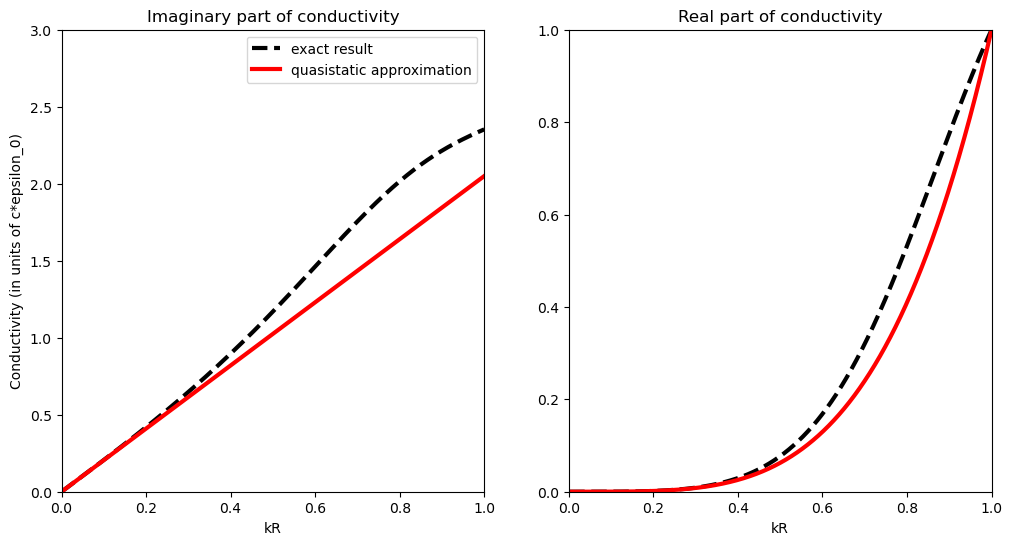

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.plot(x, quasistatic_dispersion, label="quasistatic approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 3)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.plot(x, x**4, label="", color="red", linestyle="solid", linewidth=3)

ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");

In [5]:
s_sqrds = abs(e_r_cpa(l, x, epsilon, 1j*(sigmas[0, :] + 1j*sigmas[1, :])/x))**2
tm_numerator = abs(e_r_cpa_numerator(l, x, epsilon, 1j*(sigmas[0, :] + 1j*sigmas[1, :])/x))
print("Maximum value for |s|^2: ", s_sqrds.max())
print("Maximum (absolute) value for the cpa numerator", tm_numerator.max())

Maximum value for |s|^2:  3.784555824036611e-14
Maximum (absolute) value for the cpa numerator 5.684341886080801e-13


In [6]:
hbar = 6.67*1e-16 # hbar in eV*seconds
tau = 6.4*1e-13 # scattering time in seconds
c = 3*10**17; # speed of light in nanometers per second
alpha = 1/137; # fine structure constant

In [93]:
a = c*tau*x*sigma_real/sigma_imaginary; # sphere radii at CPA
hbar_omega = hbar*(sigma_imaginary/sigma_real)*(1/tau) # angular frequencies (in eV) at CPA
E_F = (hbar/tau)*(sigma_real**2+sigma_imaginary**2)/(4*sigma_real)/alpha; # Fermi energies in eV at CPA

In [62]:
N = 10000
cpa_idxs = [5000, 6000, 7000, 8000, 9000] # Sweep from ka = 0.5 to 0.9
E_F_real_v = zeros((len(cpa_idxs), N)) 
E_F_imaginary_v = zeros((len(cpa_idxs), N))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    hbar_omega_cpa = hbar_omega[cpa_idx]
    hbar_omega_off_cpa_range = linspace(hbar_omega_cpa/4, hbar_omega_cpa*7/4, N)
    E_F_real = 1/(4*alpha)*(hbar_omega_off_cpa_range*sigma_imaginary[cpa_idx]+(hbar/tau)*sigma_real[cpa_idx])
    E_F_imaginary = 1/(4*alpha)*(-hbar_omega_off_cpa_range*sigma_real[cpa_idx]+(hbar/tau)*sigma_imaginary[cpa_idx])
    E_F_real_v[idx, :] = E_F_real
    E_F_imaginary_v[idx, :] = E_F_imaginary

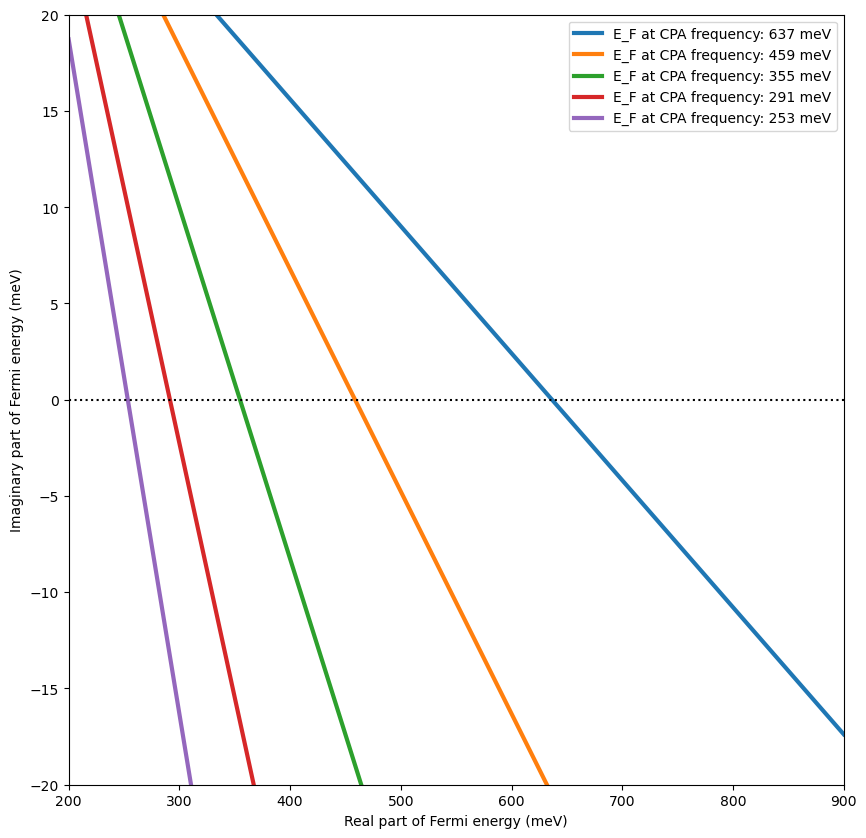

In [96]:
fig, ax = plt.subplots(figsize=(10, 10))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    E_F_real = E_F_real_v[idx, :]
    E_F_imaginary = E_F_imaginary_v[idx, :]

    E_F_CPA = E_F_real[np.argmin(np.abs(E_F_imaginary))]
    ax.plot(E_F_real*1e3, E_F_imaginary*1e3, linestyle="solid", linewidth=3, label=f"E_F at CPA frequency: {round(E_F_CPA*1e3)} meV")
ax.set_ylim(-20, 20);
ax.set_xlim(200, 900);
ax.hlines([0], 200, 900, color="black", linestyle="dotted")
ax.set_xlabel("Real part of Fermi energy (meV)")
ax.set_ylabel("Imaginary part of Fermi energy (meV)");
ax.legend();

### Now we find the correct (frequency, scattering rate) pair for a fixed Fermi energy 

In [89]:
cpa_idxs = [5000, 6000, 7000, 8000, 9000]
N = 10000
taus_v = zeros((len(cpa_idxs), N))
hbar_omegas_v = zeros((len(cpa_idxs), N))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    E_F_cpa = E_F[cpa_idx]
    E_F_off_cpa_range = linspace(E_F_cpa/3, E_F_cpa*3, N)
    taus = (hbar/E_F_off_cpa_range)*(sigma_real[cpa_idx]**2+sigma_imaginary[cpa_idx]**2)/(4*alpha*sigma_real[cpa_idx])
    hbar_omegas = E_F_off_cpa_range*(4*alpha*sigma_imaginary[cpa_idx])/(sigma_real[cpa_idx]**2+sigma_imaginary[cpa_idx]**2)
    taus_v[idx, :] = taus
    hbar_omegas_v[idx, :] = hbar_omegas

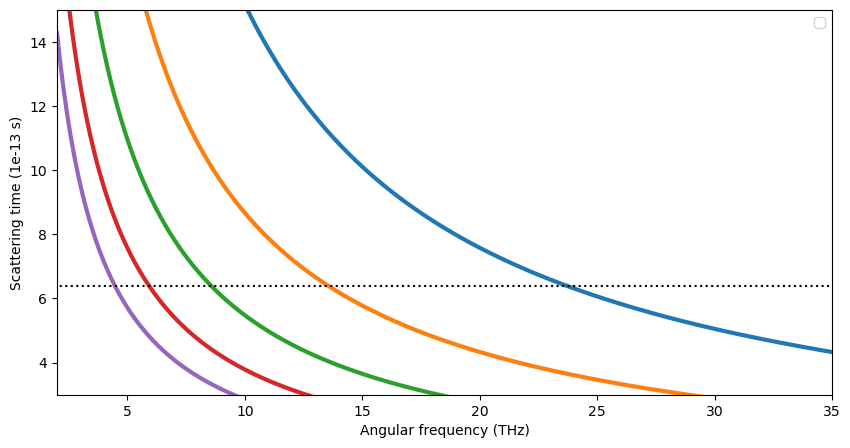

In [103]:
fig, ax = plt.subplots(figsize=(10, 5))
tau_64_idx = np.argmin(np.abs(linspace(1/3, 3, N)-1))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    taus_100fs = taus_v[idx, :]*1e13
    hbar_omegas_thz = hbar_omegas_v[idx, :]/(hbar*1e12)
    where_crosses_tau_64 = np.argmin(np.abs(taus_100fs-6.4)) 
    assert where_crosses_tau_64 == tau_64_idx # Where the lines below cross tau=6.4 should correspond to the index at which the Fermi energy is the CPA Fermi energy 
    ax.plot(hbar_omegas_thz, taus_100fs, linestyle="solid", linewidth=3)
ax.hlines([6.4], 0, 100, color="black", linestyle="dotted")
ax.set_xlabel("Angular frequency (THz)")
ax.set_ylabel("Scattering time (1e-13 s)");
ax.set_ylim(3, 15);
ax.set_xlim(2, 35);
ax.legend();